# 11 - Metric and Preprocessing Sensitivity

Notebook 07 asked whether the FLUX latent-token topology survives
sampling perturbations and simple controls. This notebook narrows in on
a related question:

> How much does the topological story change when we keep the FLUX VAE
> tokens fixed but change the metric or preprocessing view?

The default run uses the same modest scale as the earlier FLUX TDA pass:
12 images, 600 dense candidates, 95 landmarks, and `maxdim=2`. The
sweep compares raw Euclidean tokens, sphere-projected cosine-like
geometry, full covariance whitening, PCA-whitening, and a norm-only
radial view.

## What Is Being Varied?

Every observed run starts from the same FLUX VAE posterior-mean token
cloud. The only things that change are:

- the view of the token cloud: `raw`, `sphere`, `whitened`,
  `pca_whitened`, or `norm_only`;
- the density and landmark settings used before Rips persistence;
- the random seed used by candidate sampling and farthest-point
  landmarks.

Controls are run at the baseline density/landmark setting. The goal is
not to crown a correct metric. The goal is to tell whether conclusions
from one metric are robust enough to deserve cycle-level follow-up.

In [1]:
from __future__ import annotations

from pathlib import Path
import os
import sys
import time
import warnings

for candidate in [Path.cwd(), Path.cwd().parent]:
    if str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="The input point cloud has more columns than rows.*")
plt.rcParams["figure.max_open_warning"] = 120
sns.set_theme(style="whitegrid", context="notebook")

from notebook_utils.encoder_explorer import (
    DEFAULT_IMAGE_DIR,
    choose_device,
    extract_token_clouds,
    l2_normalize,
    load_project_images,
    sample_indices,
    seed_everything,
    shape_summary,
    show_image_grid,
)
from notebook_utils.flux_tda import (
    TDASample,
    farthest_point_indices,
    plot_betti_curves,
    plot_diagrams,
    ripser_diagrams,
    select_dense_indices,
    top_persistence_table,
)

## 1. Runtime Knobs

Use `TOKENIZER_SMOKE=1` for a quick execution check. The non-smoke
defaults keep the baseline setting at 12 images, 600 dense candidates,
95 landmarks, and `maxdim=2`, while adding a small sampling sweep around
that baseline.

In [2]:
def parse_int_list(text: str) -> list[int]:
    return [int(part.strip()) for part in text.split(",") if part.strip()]


def parse_str_list(text: str) -> list[str]:
    return [part.strip() for part in text.split(",") if part.strip()]


SEED = int(os.environ.get("TOKENIZER_NOTEBOOK_SEED", "72"))
SMOKE = os.environ.get("TOKENIZER_SMOKE", "0") == "1"

N_IMAGES = int(os.environ.get("TOKENIZER_N_IMAGES", "4" if SMOKE else "12"))
BATCH_SIZE = int(os.environ.get("TOKENIZER_BATCH_SIZE", "2" if SMOKE else "4"))
AUTOENCODER_SIZE = int(os.environ.get("TOKENIZER_AUTOENCODER_SIZE", "256"))
IMAGE_DIR = os.environ.get("TOKENIZER_IMAGE_DIR", str(DEFAULT_IMAGE_DIR))

SENSITIVITY_SEEDS = parse_int_list(os.environ.get("METRIC_SENSITIVITY_SEEDS", "72" if SMOKE else "72,73"))
VIEWS = parse_str_list(os.environ.get("METRIC_SENSITIVITY_VIEWS", "raw,sphere,whitened,pca_whitened,norm_only"))

N_DENSE = int(os.environ.get("METRIC_SENSITIVITY_N_DENSE", "240" if SMOKE else "600"))
N_LANDMARKS = int(os.environ.get("METRIC_SENSITIVITY_N_LANDMARKS", "45" if SMOKE else "95"))
K_DENSITY = int(os.environ.get("METRIC_SENSITIVITY_K_DENSITY", "10" if SMOKE else "16"))
PCA_WHITEN_DIM = int(os.environ.get("METRIC_SENSITIVITY_PCA_DIM", "6" if SMOKE else "8"))
MAXDIM = int(os.environ.get("METRIC_SENSITIVITY_MAXDIM", "2"))
DISTANCE_QUANTILE = float(os.environ.get("METRIC_SENSITIVITY_DISTANCE_QUANTILE", "0.82"))
CONTROL_KINDS = parse_str_list(os.environ.get("METRIC_SENSITIVITY_CONTROLS", "random_tokens,view_null"))

if SMOKE:
    SWEEP_CONFIGS = pd.DataFrame(
        [
            {"config": "baseline", "n_dense": N_DENSE, "n_landmarks": N_LANDMARKS, "k_density": K_DENSITY},
        ]
    )
else:
    SWEEP_CONFIGS = pd.DataFrame(
        [
            {"config": "baseline", "n_dense": N_DENSE, "n_landmarks": N_LANDMARKS, "k_density": K_DENSITY},
            {"config": "smaller_dense", "n_dense": min(N_DENSE, 400), "n_landmarks": N_LANDMARKS, "k_density": K_DENSITY},
            {"config": "fewer_landmarks", "n_dense": N_DENSE, "n_landmarks": min(N_LANDMARKS, 70), "k_density": K_DENSITY},
        ]
    )

seed_everything(SEED)
DEVICE = choose_device(force_cpu=os.environ.get("TOKENIZER_FORCE_CPU", "0") == "1")

display(
    pd.DataFrame(
        [
            {"knob": "device", "value": DEVICE},
            {"knob": "smoke", "value": SMOKE},
            {"knob": "n_images", "value": N_IMAGES},
            {"knob": "seeds", "value": SENSITIVITY_SEEDS},
            {"knob": "views", "value": VIEWS},
            {"knob": "controls", "value": CONTROL_KINDS},
            {"knob": "pca_whiten_dim", "value": PCA_WHITEN_DIM},
            {"knob": "maxdim", "value": MAXDIM},
            {"knob": "distance_quantile", "value": DISTANCE_QUANTILE},
            {"knob": "image_dir", "value": IMAGE_DIR},
        ]
    )
)
display(SWEEP_CONFIGS)

,knob,value
0,device,mps
1,smoke,False
2,n_images,12
3,seeds,"[72, 73]"
4,views,"[raw, sphere, whitened, pca_whitened, norm_only]"
5,controls,"[random_tokens, view_null]"
6,pca_whiten_dim,8
7,maxdim,2
8,distance_quantile,0.82
9,image_dir,/Users/vitaly/Code/latent-space-topology/data/...


,config,n_dense,n_landmarks,k_density
0,baseline,600,95,16
1,smaller_dense,400,95,16
2,fewer_landmarks,600,70,16


## 2. Load Images and Encode FLUX Once

The encoder pass is shared by every metric/preprocessing view. All
subsequent comparisons reuse the same FLUX VAE token cloud.

,image_id,source,path,label,dataset_index,width,height
0,0,beans,/Users/vitaly/Code/latent-space-topology/data/...,angular_leaf_spot,0,500,500
1,1,beans,/Users/vitaly/Code/latent-space-topology/data/...,bean_rust,345,500,500
2,2,beans,/Users/vitaly/Code/latent-space-topology/data/...,healthy,693,500,500
3,3,beans,/Users/vitaly/Code/latent-space-topology/data/...,angular_leaf_spot,1,500,500
4,4,beans,/Users/vitaly/Code/latent-space-topology/data/...,bean_rust,346,500,500
5,5,beans,/Users/vitaly/Code/latent-space-topology/data/...,healthy,694,500,500
6,6,beans,/Users/vitaly/Code/latent-space-topology/data/...,angular_leaf_spot,2,500,500
7,7,beans,/Users/vitaly/Code/latent-space-topology/data/...,bean_rust,347,500,500
8,8,beans,/Users/vitaly/Code/latent-space-topology/data/...,healthy,695,500,500
9,9,beans,/Users/vitaly/Code/latent-space-topology/data/...,angular_leaf_spot,3,500,500


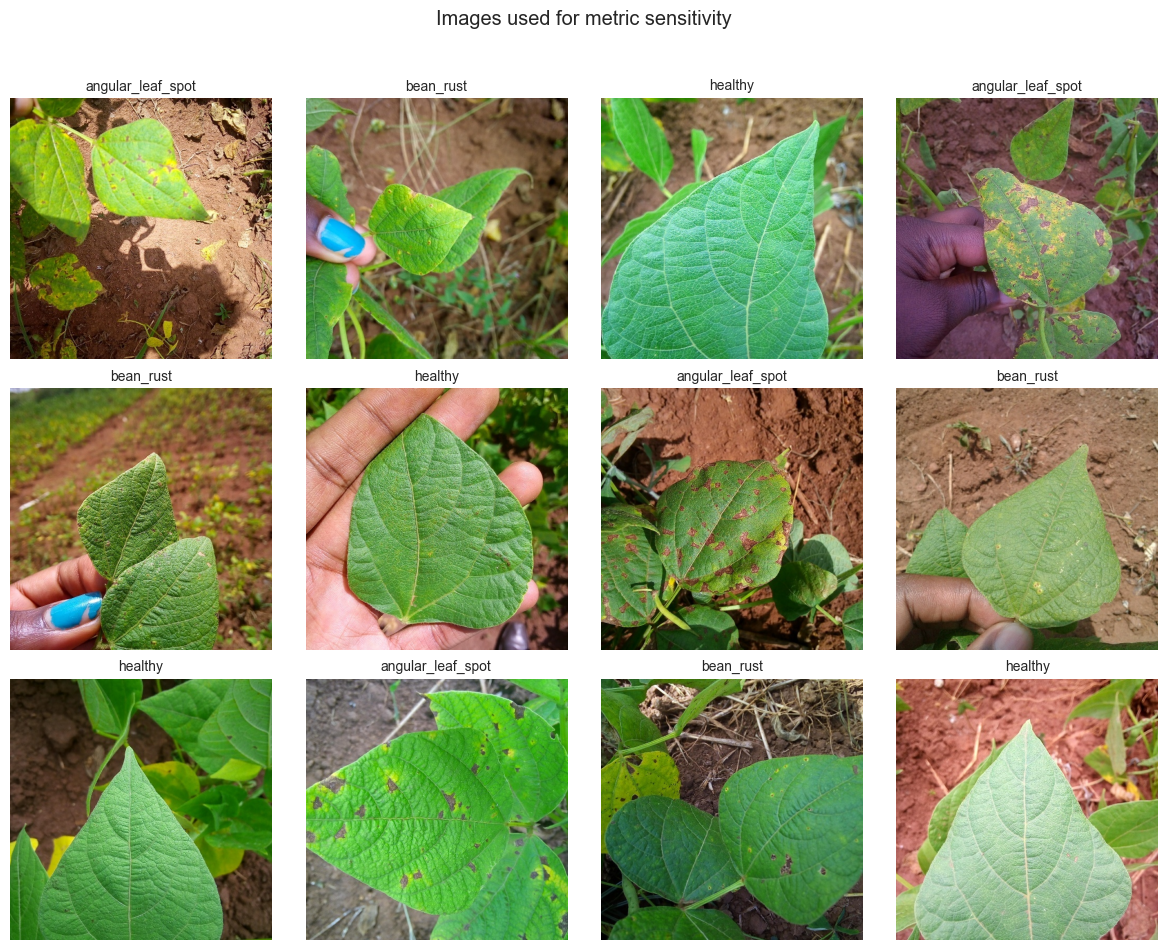

In [3]:
images, image_metadata = load_project_images(N_IMAGES, IMAGE_DIR)
display(image_metadata.head(12))
show_image_grid(images, image_metadata, n=min(12, len(images)), title="Images used for metric sensitivity")

In [4]:
t0 = time.perf_counter()
token_clouds, failures = extract_token_clouds(
    images,
    image_metadata,
    device=DEVICE,
    batch_size=BATCH_SIZE,
    autoencoder_size=AUTOENCODER_SIZE,
    selected=["flux_vae"],
)
encode_seconds = time.perf_counter() - t0

if not failures.empty:
    display(failures)

flux = token_clouds["flux_vae"]
print(f"encoding seconds: {encode_seconds:.2f}")
display(shape_summary(token_clouds))
display(pd.DataFrame([flux.notes]))

Running flux_vae: diffusers/FLUX.1-vae


/Users/vitaly/Code/latent-space-topology/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


  ok: (12288, 16), grid=(32, 32), elapsed=6.0s
encoding seconds: 5.97


,name,family,token_kind,tokens_shape,grid_shape,channel_dim,model_id
0,flux_vae,AutoencoderKL,posterior_mean,"(12288, 16)","(32, 32)",16,diffusers/FLUX.1-vae


,device,latent_shape_bchw,scaling_factor,shift_factor,scaled_latent_mean,scaled_latent_std
0,mps,"(12, 16, 32, 32)",0.3611,0.1159,-0.1058,0.730939


## 3. Build Metric and Preprocessing Views

These helper functions are intentionally local to the notebook, following
the style of notebook 07. We do not add shared utility code for this
exploratory sweep.

View definitions:

- `raw`: original FLUX posterior-mean token vectors with Euclidean
  distance;
- `sphere`: L2-normalized token directions, so Euclidean chord distance
  is cosine-like;
- `whitened`: centered full covariance whitening, then Euclidean
  distance;
- `pca_whitened`: lower-dimensional PCA whitening, useful as a denoised
  whitening view;
- `norm_only`: one-dimensional standardized token norm, isolating radial
  magnitude from direction.

In [5]:
def covariance_whiten(x: np.ndarray, eps: float = 1e-5) -> tuple[np.ndarray, dict]:
    x = x.astype(np.float32)
    centered = x - x.mean(axis=0, keepdims=True)
    cov = np.cov(centered, rowvar=False)
    values, vectors = np.linalg.eigh(cov + np.eye(cov.shape[0]) * eps)
    values = np.maximum(values, eps)
    whitened = centered @ vectors @ np.diag(1.0 / np.sqrt(values))
    return whitened.astype(np.float32), {
        "whiten_components": int(x.shape[1]),
        "eigen_min": float(values.min()),
        "eigen_max": float(values.max()),
    }


def pca_whiten_tokens(x: np.ndarray, max_dim: int, seed: int) -> tuple[np.ndarray, dict]:
    x = x.astype(np.float32)
    centered = x - x.mean(axis=0, keepdims=True)
    n_components = min(max_dim, x.shape[0] - 1, x.shape[1])
    if n_components < 1:
        return centered.copy(), {"whiten_components": int(x.shape[1]), "explained_variance_sum": np.nan}
    pca = PCA(n_components=n_components, whiten=True, random_state=seed)
    z = pca.fit_transform(centered)
    return z.astype(np.float32), {
        "whiten_components": int(n_components),
        "explained_variance_sum": float(pca.explained_variance_ratio_.sum()),
    }


def token_view_array(raw: np.ndarray, view: str, *, seed: int) -> tuple[np.ndarray, dict]:
    raw = raw.astype(np.float32)
    if view == "raw":
        return raw, {"view": "raw Euclidean", "components": int(raw.shape[1])}
    if view == "sphere":
        return l2_normalize(raw).astype(np.float32), {"view": "unit sphere chord distance", "components": int(raw.shape[1])}
    if view == "whitened":
        return covariance_whiten(raw)
    if view == "pca_whitened":
        return pca_whiten_tokens(raw, max_dim=PCA_WHITEN_DIM, seed=seed)
    if view == "norm_only":
        norms = np.linalg.norm(raw, axis=1, keepdims=True)
        centered = norms - norms.mean(axis=0, keepdims=True)
        scale = float(norms.std()) if float(norms.std()) > 1e-8 else 1.0
        return (centered / scale).astype(np.float32), {
            "view": "standardized token norm only",
            "components": 1,
            "raw_norm_mean": float(norms.mean()),
            "raw_norm_std": float(norms.std()),
        }
    raise ValueError(f"unknown view: {view}")


raw_tokens = flux.tokens.astype(np.float32)
view_tokens: dict[str, np.ndarray] = {}
view_notes: dict[str, dict] = {}
for view in VIEWS:
    view_tokens[view], view_notes[view] = token_view_array(raw_tokens, view, seed=SEED)

view_overview_rows = []
for view, x in view_tokens.items():
    distances = pdist(x[sample_indices(len(x), min(2000, len(x)), seed=SEED)], metric="euclidean")
    view_overview_rows.append(
        {
            "view": view,
            "shape": tuple(x.shape),
            "distance_median_sample": float(np.median(distances)),
            "distance_cv_sample": float(np.std(distances) / max(np.mean(distances), 1e-12)),
            **view_notes[view],
        }
    )
view_overview = pd.DataFrame(view_overview_rows)
display(view_overview)

,view,shape,distance_median_sample,distance_cv_sample,components,whiten_components,eigen_min,eigen_max,explained_variance_sum,raw_norm_mean,raw_norm_std
0,raw Euclidean,"(12288, 16)",9.583978,0.267448,16.0,NaN,NaN,NaN,NaN,NaN,NaN
1,unit sphere chord distance,"(12288, 16)",1.242222,0.241653,16.0,NaN,NaN,NaN,NaN,NaN,NaN
2,whitened,"(12288, 16)",5.508044,0.186567,NaN,16.0,0.65118,17.009868,NaN,NaN,NaN
3,pca_whitened,"(12288, 8)",3.855093,0.247849,NaN,8.0,NaN,NaN,0.846671,NaN,NaN
4,standardized token norm only,"(12288, 1)",0.948430,0.771723,1.0,NaN,NaN,NaN,NaN,7.960248,1.678583


## 4. Sampling and Persistence Helpers

This cell mirrors notebook 07's dense-set and landmark wiring, but makes
the view explicit in every sample and summary row.

In [6]:
def pairwise_distance_stats(sample: TDASample) -> dict:
    distances = pdist(sample.tokens, metric="euclidean")
    if len(distances) == 0:
        return {
            "distance_mean": 0.0,
            "distance_median": 0.0,
            "distance_iqr": 0.0,
            "distance_cv": 0.0,
        }
    q25, q75 = np.quantile(distances, [0.25, 0.75])
    mean = float(np.mean(distances))
    return {
        "distance_mean": mean,
        "distance_median": float(np.median(distances)),
        "distance_iqr": float(q75 - q25),
        "distance_cv": float(np.std(distances) / max(mean, 1e-12)),
    }


def build_observed_view_sample(
    cloud,
    view: str,
    n_dense: int,
    n_landmarks: int,
    k_density: int,
    seed: int,
) -> TDASample:
    x = view_tokens[view]
    dense_global_idx, dense_kth = select_dense_indices(x, n_dense=n_dense, k=k_density, seed=seed)
    dense_tokens = x[dense_global_idx]
    landmark_local_idx = farthest_point_indices(dense_tokens, n_landmarks=n_landmarks, seed=seed)
    landmark_global_idx = dense_global_idx[landmark_local_idx]
    return TDASample(
        name=f"observed_{view}",
        tokens=dense_tokens[landmark_local_idx],
        source_indices=landmark_global_idx,
        metadata=cloud.token_metadata.iloc[landmark_global_idx].reset_index(drop=True),
        notes={
            "view": view,
            "density": "small kth-neighbor distance in the selected view",
            "n_dense": len(dense_global_idx),
            "n_landmarks": len(landmark_global_idx),
            "k_density": k_density,
            "dense_kth_median": float(np.median(dense_kth)),
        },
    )


def build_random_view_sample(cloud, view: str, n_landmarks: int, seed: int) -> TDASample:
    x = view_tokens[view]
    idx = sample_indices(len(x), n_landmarks, seed=seed)
    return TDASample(
        name=f"random_tokens_{view}",
        tokens=x[idx],
        source_indices=idx,
        metadata=cloud.token_metadata.iloc[idx].reset_index(drop=True),
        notes={"control": "random token subset in the same view", "view": view},
    )


def build_view_null_sample(view: str, n_landmarks: int, seed: int) -> TDASample:
    rng = np.random.default_rng(seed)
    dim = view_tokens[view].shape[1]
    if view == "raw":
        idx = sample_indices(len(raw_tokens), min(5000, len(raw_tokens)), seed=seed)
        x_ref = raw_tokens[idx]
        mean = x_ref.mean(axis=0)
        cov = np.cov(x_ref, rowvar=False) + np.eye(x_ref.shape[1]) * 1e-6
        x = rng.multivariate_normal(mean, cov, size=n_landmarks).astype(np.float32)
        name = "matched_gaussian_raw_null"
        note = "Gaussian matched to raw token mean and covariance"
    elif view == "sphere":
        x = rng.normal(size=(n_landmarks, dim)).astype(np.float32)
        x = l2_normalize(x).astype(np.float32)
        name = "uniform_sphere_null"
        note = "uniform random directions on the same ambient sphere"
    elif view in {"whitened", "pca_whitened"}:
        x = rng.normal(size=(n_landmarks, dim)).astype(np.float32)
        name = f"standard_normal_{view}_null"
        note = "standard normal null in whitened coordinates"
    elif view == "norm_only":
        x = rng.normal(size=(n_landmarks, 1)).astype(np.float32)
        name = "standard_normal_norm_null"
        note = "one-dimensional standard normal radial null"
    else:
        raise ValueError(f"unknown view: {view}")
    return TDASample(
        name=name,
        tokens=x,
        source_indices=np.arange(n_landmarks),
        metadata=pd.DataFrame({"image_id": ["control"] * n_landmarks, "label": [name] * n_landmarks, "h": 0, "w": 0}),
        notes={"control": note, "view": view},
    )


def summarize_result(
    result: dict,
    sample: TDASample,
    *,
    seed: int,
    config: str,
    view: str,
    group: str,
    control_kind: str,
    n_dense: int,
    n_landmarks: int,
    k_density: int,
) -> pd.DataFrame:
    pairwise = pairwise_distance_stats(sample)
    rows = []
    for dim, diagram in enumerate(result["diagrams"]):
        finite = diagram[np.isfinite(diagram[:, 1])]
        persistence = finite[:, 1] - finite[:, 0] if len(finite) else np.array([])
        rows.append(
            {
                "seed": seed,
                "config": config,
                "view": view,
                "group": group,
                "control_kind": control_kind,
                "sample": result["sample"],
                "dim": dim,
                "n_dense": n_dense,
                "n_landmarks": n_landmarks,
                "k_density": k_density,
                "n_features": len(diagram),
                "n_finite": len(finite),
                "max_persistence": float(persistence.max()) if len(persistence) else 0.0,
                "mean_persistence": float(persistence.mean()) if len(persistence) else 0.0,
                "total_persistence": float(persistence.sum()) if len(persistence) else 0.0,
                "top3_persistence": float(np.sort(persistence)[-3:].sum()) if len(persistence) else 0.0,
                "threshold": result["threshold"],
                "max_persistence_fraction": float(persistence.max() / result["threshold"]) if len(persistence) and result["threshold"] > 0 else 0.0,
                **pairwise,
            }
        )
    return pd.DataFrame(rows)


def run_one(
    sample: TDASample,
    *,
    seed: int,
    config: str,
    view: str,
    group: str,
    control_kind: str,
    n_dense: int,
    n_landmarks: int,
    k_density: int,
) -> tuple[dict, pd.DataFrame]:
    result = ripser_diagrams(sample, maxdim=MAXDIM, distance_quantile=DISTANCE_QUANTILE)
    result["sample"] = sample.name
    result["notes"] = sample.notes
    summary = summarize_result(
        result,
        sample,
        seed=seed,
        config=config,
        view=view,
        group=group,
        control_kind=control_kind,
        n_dense=n_dense,
        n_landmarks=n_landmarks,
        k_density=k_density,
    )
    return result, summary

## 5. Run the Sensitivity Sweep

Observed FLUX runs cover every configured view, seed, and sampling
setting. Controls are limited to the baseline sampling setting to keep
runtime modest.

In [7]:
results: dict[tuple, dict] = {}
samples: dict[tuple, TDASample] = {}
summaries = []

t0 = time.perf_counter()

for cfg in SWEEP_CONFIGS.to_dict("records"):
    cfg_kwargs = {k: int(cfg[k]) for k in ["n_dense", "n_landmarks", "k_density"]}
    for seed in SENSITIVITY_SEEDS:
        for view in VIEWS:
            sample = build_observed_view_sample(flux, view=view, seed=seed, **cfg_kwargs)
            result, summary_part = run_one(
                sample,
                seed=seed,
                config=cfg["config"],
                view=view,
                group="observed",
                control_kind="observed",
                **cfg_kwargs,
            )
            key = (cfg["config"], seed, view, "observed")
            results[key] = result
            samples[key] = sample
            summaries.append(summary_part)

baseline = SWEEP_CONFIGS.iloc[0].to_dict()
baseline_kwargs = {k: int(baseline[k]) for k in ["n_dense", "n_landmarks", "k_density"]}

for seed in SENSITIVITY_SEEDS:
    for view in VIEWS:
        control_samples = []
        if "random_tokens" in CONTROL_KINDS:
            control_samples.append(("random_tokens", build_random_view_sample(flux, view=view, n_landmarks=baseline_kwargs["n_landmarks"], seed=seed + 101)))
        if "view_null" in CONTROL_KINDS:
            control_samples.append(("view_null", build_view_null_sample(view=view, n_landmarks=baseline_kwargs["n_landmarks"], seed=seed + 102)))
        for control_kind, sample in control_samples:
            result, summary_part = run_one(
                sample,
                seed=seed,
                config="baseline",
                view=view,
                group="control",
                control_kind=control_kind,
                **baseline_kwargs,
            )
            key = ("baseline", seed, view, control_kind)
            results[key] = result
            samples[key] = sample
            summaries.append(summary_part)

sweep_seconds = time.perf_counter() - t0
summary = pd.concat(summaries, ignore_index=True)

print(f"sweep seconds: {sweep_seconds:.2f}")
print(f"diagram runs: {len(results)}")
display(summary.head())
display(summary.groupby(["group", "control_kind", "view", "dim"]).size().rename("runs").reset_index())

sweep seconds: 3.71
diagram runs: 50


,seed,config,view,group,control_kind,sample,dim,n_dense,n_landmarks,k_density,...,max_persistence,mean_persistence,total_persistence,top3_persistence,threshold,max_persistence_fraction,distance_mean,distance_median,distance_iqr,distance_cv
0,72,baseline,raw,observed,observed,observed_raw,0,600,95,16,...,5.967934,4.320461,406.123311,15.386823,11.269696,0.529556,8.498817,8.256186,4.432630,0.308268
1,72,baseline,raw,observed,observed,observed_raw,1,600,95,16,...,0.933737,0.270213,28.372412,2.388353,11.269696,0.082854,8.498817,8.256186,4.432630,0.308268
2,72,baseline,raw,observed,observed,observed_raw,2,600,95,16,...,0.541062,0.136852,7.800590,1.341378,11.269696,0.048010,8.498817,8.256186,4.432630,0.308268
3,72,baseline,sphere,observed,observed,observed_sphere,0,600,95,16,...,1.039958,0.462606,43.484963,2.108157,1.151979,0.902758,0.848397,0.746691,0.356541,0.370159
4,72,baseline,sphere,observed,observed,observed_sphere,1,600,95,16,...,0.091637,0.033571,3.659266,0.260855,1.151979,0.079548,0.848397,0.746691,0.356541,0.370159


,group,control_kind,view,dim,runs
0,control,random_tokens,norm_only,0,2
1,control,random_tokens,norm_only,1,2
2,control,random_tokens,norm_only,2,2
3,control,random_tokens,pca_whitened,0,2
4,control,random_tokens,pca_whitened,1,2
5,control,random_tokens,pca_whitened,2,2
6,control,random_tokens,raw,0,2
7,control,random_tokens,raw,1,2
8,control,random_tokens,raw,2,2
9,control,random_tokens,sphere,0,2


## 6. Observed View Sensitivity

This is the main sensitivity plot. It uses only observed FLUX samples and
asks whether normalized persistence moves more across preprocessing
views than across the small density/landmark sweep.

max_persistence_fraction         n_finite  \
                                                     mean     std     mean   
view         config          dim                                             
norm_only    baseline        1                     0.0000  0.0000      0.0   
                             2                     0.0000  0.0000      0.0   
             fewer_landmarks 1                     0.0000  0.0000      0.0   
                             2                     0.0000  0.0000      0.0   
             smaller_dense   1                     0.0000  0.0000      0.0   
                             2                     0.0000  0.0000      0.0   
pca_whitened baseline        1                     0.1524  0.0176     96.0   
                             2                     0.0762  0.0078     56.0   
             fewer_landmarks 1                     0.1587  0.0247     66.5   
                             2                     0.0935  0.0118     42.5   
             smaller_dense   1                     0.1270  0.0287     79.5   
                             2                     0.0772  0.0049     44.5   
raw          baseline        1                     0.0739  0.0127    100.5   
                             2                     0.0498  0.0026     65.5   
             fewer_landmarks 1                     0.0623  0.0013     63.5   
                             2                     0.0413  0.0050     30.5   
             smaller_dense   1                     0.0764  0.0076     80.0   
                             2                     0.0447  0.0009     41.5   
sphere       baseline        1                     0.0760  0.0050    115.0   
                             2                     0.0438  0.0078     86.5   
             fewer_landmarks 1                     0.0704  0.0064     70.0   
                             2                     0.0406  0.0026     38.0   
             smaller_dense   1                     0.0729  0.0104    106.5   
                             2                     0.0429  0.0110     78.5   
whitened     baseline        1                     0.1074  0.0055    163.0   
                             2                     0.0730  0.0125    195.5   
             fewer_landmarks 1                     0.1161  0.0211    106.5   
                             2                     0.0796  0.0091    124.0   
             smaller_dense   1                     0.1106  0.0165    151.5   
                             2                     0.0670  0.0085    151.5   

                                          total_persistence          \
                                      std              mean     std   
view         config          dim                                      
norm_only    baseline        1     0.0000            0.0000  0.0000   
                             2     0.0000            0.0000  0.0000   
             fewer_landmarks 1     0.0000            0.0000  0.0000   
                             2     0.0000            0.0000  0.0000   
             smaller_dense   1     0.0000            0.0000  0.0000   
                             2     0.0000            0.0000  0.0000   
pca_whitened baseline        1     9.8995           13.9851  1.0105   
                             2     1.4142            5.2472  0.1275   
             fewer_landmarks 1     9.1924           11.4394  0.5701   
                             2     3.5355            5.1911  0.1824   
             smaller_dense   1     7.7782           11.8915  0.1299   
                             2    13.4350            3.4357  0.9625   
raw          baseline        1     6.3640           27.0532  1.8656   
                             2    12.0208           10.2469  3.4596   
             fewer_landmarks 1     6.3640           18.7668  1.3391   
                             2     3.5355            4.8021  1.2339   
             smaller_dense   1     0.0000           20.9119  0.5401   
                             2     9.1

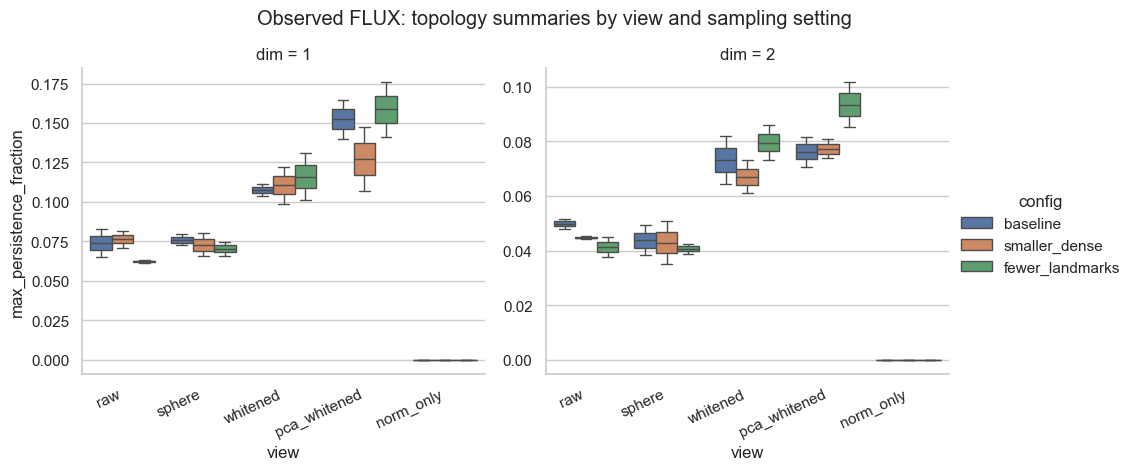

In [8]:
observed = summary[summary["group"] == "observed"].copy()
higher_dims = [dim for dim in [1, 2] if dim <= MAXDIM]
observed_higher = observed[observed["dim"].isin(higher_dims)].copy()

if observed_higher.empty:
    print("No H1/H2 rows available for the current MAXDIM.")
else:
    display(
        observed_higher
        .groupby(["view", "config", "dim"])
        [["max_persistence_fraction", "n_finite", "total_persistence", "distance_cv"]]
        .agg(["mean", "std"])
        .round(4)
    )

    g = sns.catplot(
        data=observed_higher,
        x="view",
        y="max_persistence_fraction",
        hue="config",
        col="dim",
        kind="box",
        height=4.1,
        aspect=1.2,
        sharey=False,
    )
    g.set_xticklabels(rotation=25, horizontalalignment="right")
    g.fig.suptitle("Observed FLUX: topology summaries by view and sampling setting", y=1.05)
    plt.show()

## 7. Distance Geometry Diagnostics

Before interpreting persistence, check whether a view simply spreads or
compresses pairwise distances. Strong distance concentration can make
normalized persistence look different even when the underlying samples
have similar structure.

threshold         distance_median         distance_cv  \
                      mean     std            mean     std        mean   
view         dim                                                         
norm_only    1      0.7534  0.0346          0.3836  0.0118      0.7329   
             2      0.7534  0.0346          0.3836  0.0118      0.7329   
pca_whitened 1      3.5858  0.0254          3.0003  0.0127      0.2197   
             2      3.5858  0.0254          3.0003  0.0127      0.2197   
raw          1     11.2441  0.0362          8.2946  0.0543      0.3118   
             2     11.2441  0.0362          8.2946  0.0543      0.3118   
sphere       1      1.1559  0.0055          0.7448  0.0027      0.3761   
             2      1.1559  0.0055          0.7448  0.0027      0.3761   
whitened     1      4.8859  0.0435          4.3164  0.0488      0.1403   
             2      4.8859  0.0435          4.3164  0.0488      0.1403   

                         max_persistence_fraction          
                     std                     mean     std  
view         dim                                           
norm_only    1    0.0141                   0.0000  0.0000  
             2    0.0141                   0.0000  0.0000  
pca_whitened 1    0.0041                   0.1524  0.0176  
             2    0.0041                   0.0762  0.0078  
raw          1    0.0050                   0.0739  0.0127  
             2    0.0050                   0.0498  0.0026  
sphere       1    0.0084                   0.0760  0.0050  
             2    0.0084                   0.0438  0.0078  
whitened     1    0.0007                   0.1074  0.0055  
             2    0.0007                   0.0730  0.0125

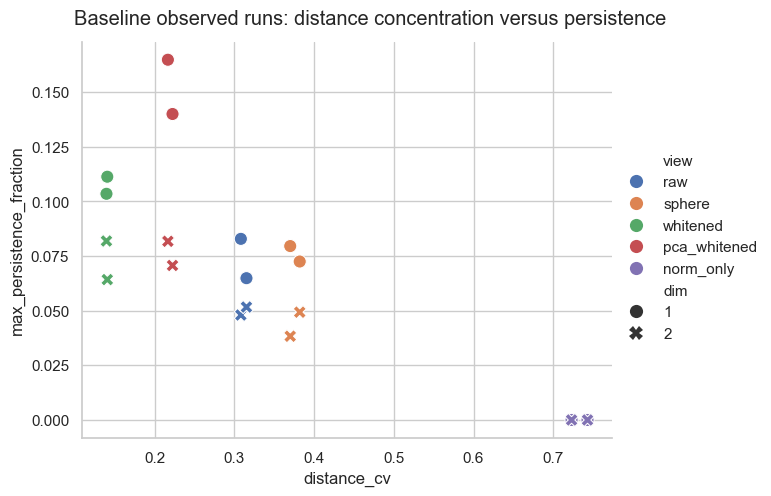

In [9]:
baseline_observed = observed[(observed["config"] == "baseline") & (observed["dim"].isin(higher_dims))].copy()
if baseline_observed.empty:
    print("No baseline observed H1/H2 rows to diagnose.")
else:
    display(
        baseline_observed
        .groupby(["view", "dim"])
        [["threshold", "distance_median", "distance_cv", "max_persistence_fraction"]]
        .agg(["mean", "std"])
        .round(4)
    )

    g = sns.relplot(
        data=baseline_observed,
        x="distance_cv",
        y="max_persistence_fraction",
        hue="view",
        style="dim",
        kind="scatter",
        height=4.8,
        aspect=1.35,
        s=90,
    )
    g.fig.suptitle("Baseline observed runs: distance concentration versus persistence", y=1.03)
    plt.show()

## 8. Observed Versus Controls

Controls are not proof or disproof, but they stop us from over-reading a
bar that appears just because a view was whitened, projected to a sphere,
or collapsed to one dimension.

max_persistence_fraction         n_finite  \
                                                   mean     std     mean   
view         sample_family dim                                             
norm_only    observed      1                     0.0000  0.0000      0.0   
                           2                     0.0000  0.0000      0.0   
             random_tokens 1                     0.0000  0.0000      0.0   
                           2                     0.0000  0.0000      0.0   
             view_null     1                     0.0000  0.0000      0.0   
                           2                     0.0000  0.0000      0.0   
pca_whitened observed      1                     0.1524  0.0176     96.0   
                           2                     0.0762  0.0078     56.0   
             random_tokens 1                     0.1423  0.0049     67.5   
                           2                     0.0435  0.0008     29.0   
             view_null     1                     0.1101  0.0056     61.5   
                           2                     0.0398  0.0069     21.5   
raw          observed      1                     0.0739  0.0127    100.5   
                           2                     0.0498  0.0026     65.5   
             random_tokens 1                     0.0914  0.0112     55.5   
                           2                     0.0314  0.0000     20.0   
             view_null     1                     0.1088  0.0024     57.0   
                           2                     0.0459  0.0010     14.5   
sphere       observed      1                     0.0760  0.0050    115.0   
                           2                     0.0438  0.0078     86.5   
             random_tokens 1                     0.1565  0.0071     64.0   
                           2                     0.0564  0.0199     22.5   
             view_null     1                     0.1357  0.0080    151.0   
                           2                     0.0778  0.0050    221.0   
whitened     observed      1                     0.1074  0.0055    163.0   
                           2                     0.0730  0.0125    195.5   
             random_tokens 1                     0.1020  0.0000     77.0   
                           2                     0.0541  0.0124     40.0   
             view_null     1                     0.1168  0.0279     72.5   
                           2                     0.0490  0.0067     43.0   

                                        top3_persistence          
                                    std             mean     std  
view         sample_family dim                                    
norm_only    observed      1     0.0000           0.0000  0.0000  
                           2     0.0000           0.0000  0.0000  
             random_tokens 1     0.0000           0.0000  0.0000  
                           2     0.0000           0.0000  0.0000  
             view_null     1     0.0000           0.0000  0.0000  
                           2     0.0000           0.0000  0.0000  
pca_whitened observed      1     9.8995           1.3854  0.1398  
                           2     1.4142           0.7584  0.0687  
             random_tokens 1     4.9497           1.7331  0.0106  
                           2     0.0000           0.5569  0.0109  
             view_null     1     9.1924           1.4481  0.0583  
                           2     6.3640           0.5112  0.0541  
raw          observed      1     6.3640           2.2459  0.2014  
                           2    12.0208           1.4759  0.1903  
             random_tokens 1    10.6066           3.0652  0.4728  
                           2     8.4853           1.0355  0.0032  
             view_null     1     5.6569           3.1594  0.1486  
                           2     3.5355           1.2910  0.1792  
sphere       observed      1     8.4853           0.2539  0.0098  
                           2     7.7782         

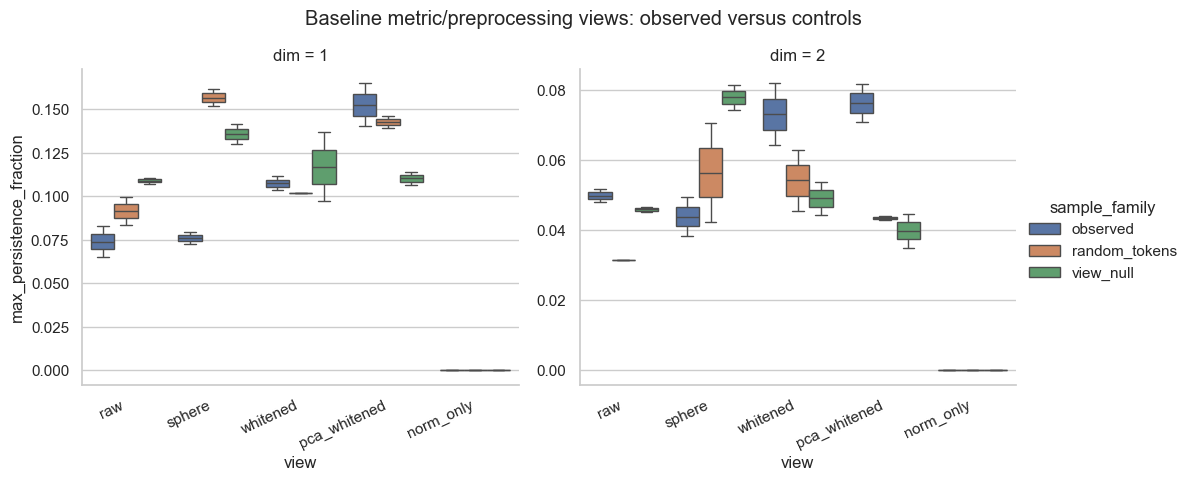

In [10]:
baseline_summary = summary[(summary["config"] == "baseline") & (summary["dim"].isin(higher_dims))].copy()
baseline_summary["sample_family"] = np.where(
    baseline_summary["group"] == "observed",
    "observed",
    baseline_summary["control_kind"],
)

if baseline_summary.empty:
    print("No baseline H1/H2 rows to compare.")
else:
    display(
        baseline_summary
        .groupby(["view", "sample_family", "dim"])
        [["max_persistence_fraction", "n_finite", "top3_persistence"]]
        .agg(["mean", "std"])
        .round(4)
    )

    g = sns.catplot(
        data=baseline_summary,
        x="view",
        y="max_persistence_fraction",
        hue="sample_family",
        col="dim",
        kind="box",
        height=4.2,
        aspect=1.25,
        sharey=False,
    )
    g.set_xticklabels(rotation=25, horizontalalignment="right")
    g.fig.suptitle("Baseline metric/preprocessing views: observed versus controls", y=1.05)
    plt.show()

## 9. Controls-Adjusted Readout

For each view and homology dimension, this table subtracts the strongest
baseline control mean from the observed mean. Positive values mean the
observed dense landmarks are above the hardest control in that view.

,view,dim,observed_mean,hardest_control,hardest_control_mean,delta_vs_hardest_control
2,pca_whitened,1,0.1524,random_tokens,0.1423,0.0101
0,norm_only,1,0.0000,view_null,0.0000,0.0000
8,whitened,1,0.1074,view_null,0.1168,-0.0094
4,raw,1,0.0739,view_null,0.1088,-0.0349
6,sphere,1,0.0760,random_tokens,0.1565,-0.0804
3,pca_whitened,2,0.0762,random_tokens,0.0435,0.0327
9,whitened,2,0.0730,random_tokens,0.0541,0.0189
5,raw,2,0.0498,view_null,0.0459,0.0039
1,norm_only,2,0.0000,view_null,0.0000,0.0000
7,sphere,2,0.0438,view_null,0.0778,-0.0340


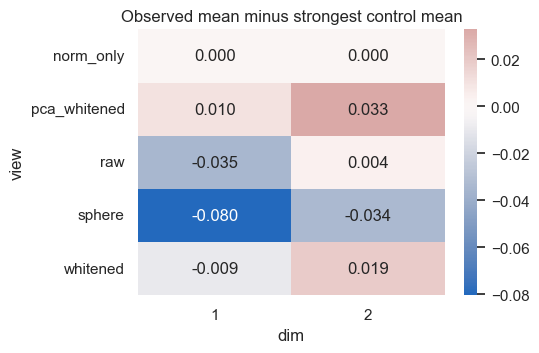

In [11]:
if baseline_summary.empty:
    effect = pd.DataFrame()
    print("No baseline summary available.")
else:
    observed_mean = (
        baseline_summary[baseline_summary["group"] == "observed"]
        .groupby(["view", "dim"], as_index=False)["max_persistence_fraction"]
        .mean()
        .rename(columns={"max_persistence_fraction": "observed_mean"})
    )
    control_means = (
        baseline_summary[baseline_summary["group"] == "control"]
        .groupby(["view", "dim", "control_kind"], as_index=False)["max_persistence_fraction"]
        .mean()
        .rename(columns={"max_persistence_fraction": "control_mean"})
    )
    hardest_control = (
        control_means.sort_values("control_mean", ascending=False)
        .drop_duplicates(["view", "dim"])
        .rename(columns={"control_mean": "hardest_control_mean", "control_kind": "hardest_control"})
    )
    effect = observed_mean.merge(hardest_control, on=["view", "dim"], how="left")
    effect["delta_vs_hardest_control"] = effect["observed_mean"] - effect["hardest_control_mean"]
    effect = effect.sort_values(["dim", "delta_vs_hardest_control"], ascending=[True, False])
    display(effect.round(4))

    if not effect.empty:
        heat = effect.pivot(index="view", columns="dim", values="delta_vs_hardest_control")
        fig, ax = plt.subplots(figsize=(5.5, 3.7))
        sns.heatmap(heat, annot=True, fmt=".3f", cmap="vlag", center=0, ax=ax)
        ax.set_title("Observed mean minus strongest control mean")
        plt.tight_layout()
        plt.show()

## 10. How Much Does the Story Change?

This table compares between-view variation with variation from the
density/landmark sweep. A large `metric_vs_sampling_ratio` says the
metric/preprocessing choice moves the summary more than the local
sampling knobs did.

In [12]:
def classify_range(range_fraction: float) -> str:
    if not np.isfinite(range_fraction):
        return "insufficient_data"
    if range_fraction >= 0.75:
        return "strongly_metric_sensitive"
    if range_fraction >= 0.35:
        return "moderately_metric_sensitive"
    return "comparatively_stable"


sensitivity_rows = []
if observed_higher.empty:
    sensitivity = pd.DataFrame()
    print("No observed H1/H2 rows available.")
else:
    view_means = (
        observed_higher
        .groupby(["view", "dim"], as_index=False)["max_persistence_fraction"]
        .mean()
    )
    config_means = (
        observed_higher
        .groupby(["config", "dim"], as_index=False)["max_persistence_fraction"]
        .mean()
    )
    for dim in sorted(view_means["dim"].unique()):
        vm = view_means[view_means["dim"] == dim].sort_values("max_persistence_fraction", ascending=False)
        cm = config_means[config_means["dim"] == dim]
        view_range = float(vm["max_persistence_fraction"].max() - vm["max_persistence_fraction"].min())
        config_count = int(cm["config"].nunique()) if len(cm) else 0
        config_range = float(cm["max_persistence_fraction"].max() - cm["max_persistence_fraction"].min()) if config_count > 1 else np.nan
        metric_vs_sampling_ratio = view_range / config_range if np.isfinite(config_range) and config_range > 1e-12 else np.nan
        mean_level = float(vm["max_persistence_fraction"].mean())
        range_fraction = view_range / max(abs(mean_level), 1e-12)
        sensitivity_rows.append(
            {
                "dim": int(dim),
                "top_view": str(vm.iloc[0]["view"]),
                "bottom_view": str(vm.iloc[-1]["view"]),
                "view_rank_order": " > ".join(vm["view"].tolist()),
                "view_mean_range": view_range,
                "view_range_fraction": range_fraction,
                "sampling_config_range": config_range,
                "metric_vs_sampling_ratio": metric_vs_sampling_ratio,
                "readout": classify_range(range_fraction),
            }
        )
    sensitivity = pd.DataFrame(sensitivity_rows)
    display(sensitivity.round(4))

,dim,top_view,bottom_view,view_rank_order,view_mean_range,view_range_fraction,sampling_config_range,metric_vs_sampling_ratio,readout
0,1,pca_whitened,norm_only,pca_whitened > whitened > sphere > raw > norm_...,0.1460,1.8196,0.0046,32.0565,strongly_metric_sensitive
1,2,pca_whitened,norm_only,pca_whitened > whitened > raw > sphere > norm_...,0.0823,1.6920,0.0046,17.9543,strongly_metric_sensitive


## 11. Representative Diagrams

Summary tables carry the main evidence. These diagrams are a sanity
check for the first seed at the baseline setting.

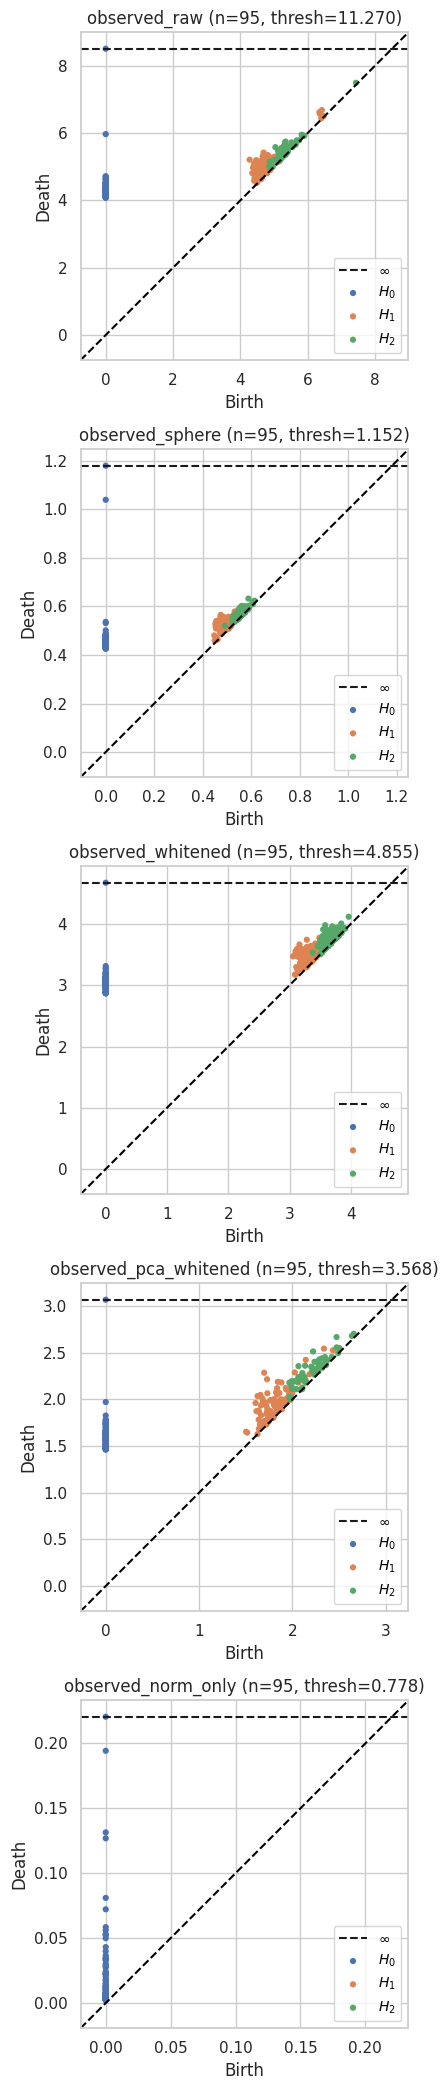

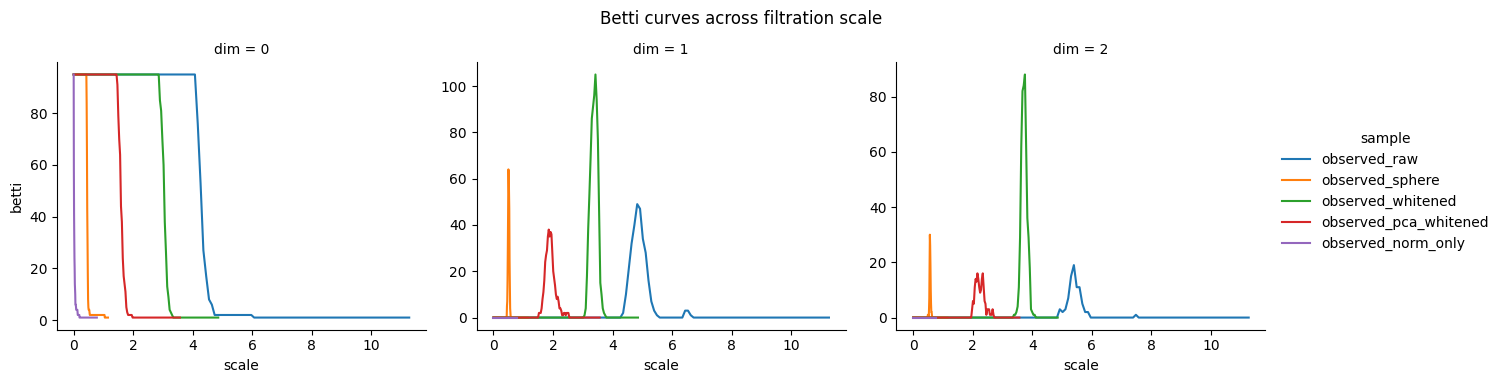

In [13]:
representative_seed = SENSITIVITY_SEEDS[0]
representative_results = [
    results[("baseline", representative_seed, view, "observed")]
    for view in VIEWS
    if ("baseline", representative_seed, view, "observed") in results
]
if representative_results:
    plot_diagrams(representative_results)
    plot_betti_curves(representative_results)
else:
    print("No representative observed diagrams available.")

## 12. Longest Bars by View

The table below lists the longest finite bars for the representative
observed run in each view. Treat it as triage, not as cycle
interpretation.

In [14]:
top_tables = []
for view in VIEWS:
    key = ("baseline", representative_seed, view, "observed")
    if key in results:
        top_tables.append(top_persistence_table(results[key], top_n=6).assign(view=view, run_key=str(key)))

if top_tables:
    display(pd.concat(top_tables, ignore_index=True))
else:
    print("No top-persistence tables available.")

,sample,dim,rank,birth,death,persistence,threshold,view,run_key
0,observed_raw,0,1,0.0,5.967934,5.967934,11.269696,raw,"('baseline', 72, 'raw', 'observed')"
1,observed_raw,0,2,0.0,4.717876,4.717876,11.269696,raw,"('baseline', 72, 'raw', 'observed')"
2,observed_raw,0,3,0.0,4.701013,4.701013,11.269696,raw,"('baseline', 72, 'raw', 'observed')"
3,observed_raw,0,4,0.0,4.660705,4.660705,11.269696,raw,"('baseline', 72, 'raw', 'observed')"
4,observed_raw,0,5,0.0,4.641001,4.641001,11.269696,raw,"('baseline', 72, 'raw', 'observed')"
...,...,...,...,...,...,...,...,...,...
73,observed_norm_only,0,2,0.0,0.131422,0.131422,0.777867,norm_only,"('baseline', 72, 'norm_only', 'observed')"
74,observed_norm_only,0,3,0.0,0.126893,0.126893,0.777867,norm_only,"('baseline', 72, 'norm_only', 'observed')"
75,observed_norm_only,0,4,0.0,0.080985,0.080985,0.777867,norm_only,"('baseline', 72, 'norm_only', 'observed')"
76,observed_norm_only,0,5,0.0,0.072201,0.072201,0.777867,norm_only,"('baseline', 72, 'norm_only', 'observed')"


## 13. Final Readout

The printed lines below are the notebook's project-log summary: runtime,
diagram count, metric sensitivity, and whether any baseline observed
view clears its strongest control.

In [15]:
print("Runtime recap")
print(f"  encode seconds: {encode_seconds:.2f}")
print(f"  sweep seconds:  {sweep_seconds:.2f}")
print(f"  diagram runs:   {len(results)}")
print()

if not sensitivity.empty:
    print("Metric/preprocessing sensitivity")
    display(sensitivity.round(4))
    for row in sensitivity.to_dict("records"):
        print(
            f"  H{row['dim']}: {row['readout']} "
            f"(top={row['top_view']}, bottom={row['bottom_view']}, "
            f"view_range_fraction={row['view_range_fraction']:.3f}, "
            f"metric_vs_sampling_ratio={row['metric_vs_sampling_ratio']:.2f})"
        )
else:
    print("Metric/preprocessing sensitivity: not available.")

if not effect.empty:
    print()
    print("Controls-adjusted baseline means")
    display(effect.round(4))
    winners = effect[effect["delta_vs_hardest_control"] > 0].copy()
    if winners.empty:
        print("  No observed view beats its strongest baseline control on mean normalized persistence.")
    else:
        display(winners.sort_values("delta_vs_hardest_control", ascending=False).round(4))
        print("  Views above their controls are candidates for follow-up cycle localization.")

print()
print(
    "Interpretation prompt: if the topological ranking changes sharply across raw, sphere, "
    "whitened, PCA-whitened, and norm-only views, treat any single-view story as "
    "metric/preprocessing-sensitive until a cycle-level analysis explains the difference."
)

Runtime recap
  encode seconds: 5.97
  sweep seconds:  3.71
  diagram runs:   50

Metric/preprocessing sensitivity


,dim,top_view,bottom_view,view_rank_order,view_mean_range,view_range_fraction,sampling_config_range,metric_vs_sampling_ratio,readout
0,1,pca_whitened,norm_only,pca_whitened > whitened > sphere > raw > norm_...,0.1460,1.8196,0.0046,32.0565,strongly_metric_sensitive
1,2,pca_whitened,norm_only,pca_whitened > whitened > raw > sphere > norm_...,0.0823,1.6920,0.0046,17.9543,strongly_metric_sensitive


  H1: strongly_metric_sensitive (top=pca_whitened, bottom=norm_only, view_range_fraction=1.820, metric_vs_sampling_ratio=32.06)
  H2: strongly_metric_sensitive (top=pca_whitened, bottom=norm_only, view_range_fraction=1.692, metric_vs_sampling_ratio=17.95)

Controls-adjusted baseline means


,view,dim,observed_mean,hardest_control,hardest_control_mean,delta_vs_hardest_control
2,pca_whitened,1,0.1524,random_tokens,0.1423,0.0101
0,norm_only,1,0.0000,view_null,0.0000,0.0000
8,whitened,1,0.1074,view_null,0.1168,-0.0094
4,raw,1,0.0739,view_null,0.1088,-0.0349
6,sphere,1,0.0760,random_tokens,0.1565,-0.0804
3,pca_whitened,2,0.0762,random_tokens,0.0435,0.0327
9,whitened,2,0.0730,random_tokens,0.0541,0.0189
5,raw,2,0.0498,view_null,0.0459,0.0039
1,norm_only,2,0.0000,view_null,0.0000,0.0000
7,sphere,2,0.0438,view_null,0.0778,-0.0340


,view,dim,observed_mean,hardest_control,hardest_control_mean,delta_vs_hardest_control
3,pca_whitened,2,0.0762,random_tokens,0.0435,0.0327
9,whitened,2,0.0730,random_tokens,0.0541,0.0189
2,pca_whitened,1,0.1524,random_tokens,0.1423,0.0101
5,raw,2,0.0498,view_null,0.0459,0.0039


  Views above their controls are candidates for follow-up cycle localization.

Interpretation prompt: if the topological ranking changes sharply across raw, sphere, whitened, PCA-whitened, and norm-only views, treat any single-view story as metric/preprocessing-sensitive until a cycle-level analysis explains the difference.
